In [62]:
from py_experimenter.experimenter import PyExperimenter
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns


# Get Data

In [63]:
update_data = False

In [64]:
def get_data(table_name:str, update_data) -> [pd.DataFrame, pd.DataFrame]:
    if update_data:
        experimenter = PyExperimenter(experiment_configuration_file_path="conf/experiment_config.yml",
                                database_credential_file_path="conf/database_credentials.yml",
                                table_name=table_name)
        main_table = experimenter.get_table()
        log_table = experimenter.get_logtable("sh_iterations")

        main_table.to_csv(f"plain_data/{table_name}/table.csv", index=False)
        log_table.to_csv(f"plain_data/{table_name}/logtable.csv", index=False)
    else:
        main_table = pd.read_csv(f"plain_data/{table_name}/table.csv")
        log_table = pd.read_csv(f"plain_data/{table_name}/logtable.csv")

    return main_table, log_table


In [65]:
final_results_table, final_results_logtable = get_data("all_results", update_data)
sensitivity_study_table, sensitivity_study_logtable = get_data("sensitivity_study", update_data)
successive_halving_table, successive_halving_logtable = get_data("successive_halving", update_data)


# Merge DataFrames

In [66]:
def merge_dataframes(main_df: pd.DataFrame, log_df: pd.DataFrame, ) -> pd.DataFrame:
    log_df = log_df.drop(columns=["ID"], errors='ignore')
    return main_df.merge(log_df, left_on="ID", right_on="experiment_id", how="left", suffixes=('_final', '_logtable'))

def subselect_max_budget_entries(merged_df: pd.DataFrame, num_arms:int) -> pd.DataFrame:
    idx = merged_df.groupby('ID')['iteration'].transform(max) == merged_df['iteration']
    merged_df = merged_df[idx]
    merged_df = merged_df[merged_df["num_arms_final"] == num_arms]
    return merged_df

final_results_table = merge_dataframes(final_results_table, final_results_logtable)
merged_sensitivity_study = merge_dataframes(sensitivity_study_table, sensitivity_study_logtable)
merged_successive_halving = merge_dataframes(successive_halving_table, successive_halving_logtable)

final_results_table = subselect_max_budget_entries(final_results_table, 256)
merged_sensitivity_study = subselect_max_budget_entries(merged_sensitivity_study, 256)
merged_successive_halving = subselect_max_budget_entries(merged_successive_halving, 256)

/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_10608/1896716305.py:6: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  idx = merged_df.groupby('ID')['iteration'].transform(max) == merged_df['iteration']


In [67]:
def create_table_summary(merged_df: pd.DataFrame) -> pd.DataFrame:
    return merged_df.groupby("prior").agg(
        avg_consumed_budget=pd.NamedAgg(column="consumed_budget", aggfunc="mean"),
        std_consumed_budget=pd.NamedAgg(column="consumed_budget", aggfunc="std"),
        avg_regret=pd.NamedAgg(column="regret", aggfunc="mean"),
        std_regret=pd.NamedAgg(column="regret", aggfunc="std"),
    ).reset_index()

# Ablation Plots
GIST: Echte performance besser als predicted performance.
Hyperparmater haben impact, aber mit linear kernel und rank prior haben wir einen sehr konsistent speedup.

In [68]:
real_performance_sensitivity = merged_sensitivity_study[merged_sensitivity_study["use_predicted_y"] == False]
predicted_performance_sensitivity = merged_sensitivity_study[merged_sensitivity_study["use_predicted_y"] == True]

In [69]:
def sensitivity_plots(merged_df: pd.DataFrame, merged_successive_halving: pd.DataFrame, benchmark_name: str, fig_title: str, sigmas:list[float], hue:str = None):
    def create_boxplot(sigma_data,x,y,ax):
        # Set more obvious colors in the plot
        if hue is not None:
            sns.boxplot(data=sigma_data, x=x, y=y, hue=hue, ax=ax, palette="Set2")
        else:
            sns.boxplot(data=sigma_data, x=x, y=y, ax=ax, palette="Set2")

    fig, ax = plt.subplots(3, 3, figsize=(18, 18))
    mean_merged_successive_halving_regret = merged_successive_halving["regret"].mean()
    std_merged_successive_halving_regret = merged_successive_halving["regret"].std()
    mean_merged_successive_halving_consumed_budget = merged_successive_halving["consumed_budget"].mean()
    std_merged_successive_halving_consumed_budget = merged_successive_halving["consumed_budget"].std()
    print(f"Successive Halving Mean Regret: {mean_merged_successive_halving_regret}, Std Dev: {std_merged_successive_halving_regret}")
    print(f"Successive Halving Mean Consumed Budget: {mean_merged_successive_halving_consumed_budget}, Std Dev: {std_merged_successive_halving_consumed_budget}")

    for plot_number, sigma in enumerate(sigmas):
        sigma_data = merged_df[merged_df["sigma0"] == sigma]
        create_boxplot(sigma_data, "prior", "regret", ax[plot_number, 0])
        ax[plot_number, 0].set_title(f"Regret Distribution for {benchmark_name}")
        ax[plot_number, 0].set_ylabel("Regret")
        ax[plot_number, 0].set_xlabel("Prior")
        ax[plot_number, 0].set_ylim(0, 0.3)
        ax[plot_number, 0].axhline(y=mean_merged_successive_halving_regret, color='r', linestyle='-', label='Successive Halving Mean Regret')
        # add shaded area for std dev
        ax[plot_number, 0].axhline(y=mean_merged_successive_halving_regret + std_merged_successive_halving_regret, color='r', linestyle=':', label='Successive Halving +1 Std Dev')
        ax[plot_number, 0].axhline(y=mean_merged_successive_halving_regret - std_merged_successive_halving_regret, color='r', linestyle=':', label='Successive Halving -1 Std Dev')

        # Create boxplot for consumed budget
        create_boxplot(sigma_data, "prior", "consumed_budget", ax[plot_number, 1])
        ax[plot_number, 1].set_title(f"Consumed Budget Distribution for {benchmark_name}")
        ax[plot_number, 1].set_ylabel("Consumed Budget")
        ax[plot_number, 1].set_xlabel("Prior")
        ax[plot_number, 1].axhline(y=mean_merged_successive_halving_consumed_budget, color='r', linestyle='-', label='Successive Halving Mean Consumed Budget')
        ax[plot_number, 1].axhline(y=mean_merged_successive_halving_consumed_budget + std_merged_successive_halving_consumed_budget, color='r', linestyle=':', label='Successive Halving +1 Std Dev')
        ax[plot_number, 1].axhline(y=mean_merged_successive_halving_consumed_budget - std_merged_successive_halving_consumed_budget, color='r', linestyle=':', label='Successive Halving -1 Std Dev')
        
        # Plot budget_spent_so_far
        create_boxplot(sigma_data, "prior", "iteration", ax[plot_number, 2])
        ax[plot_number, 2].set_title(f"Max Fidelity Level Reached for {benchmark_name}")
        ax[plot_number, 2].set_ylabel("Max fidelity level reached")
        ax[plot_number, 2].set_xlabel("Prior")

        fig.suptitle(fig_title)
        fig.tight_layout()
        fig.show()

## Sensitivity, with varying delta
### Predicted Performance

Successive Halving Mean Regret: 0.022693028068542453, Std Dev: 0.039084108962017146
Successive Halving Mean Consumed Budget: 1152.0, Std Dev: 0.0


/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_10608/2758826522.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_10608/2758826522.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_10608/2758826522.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


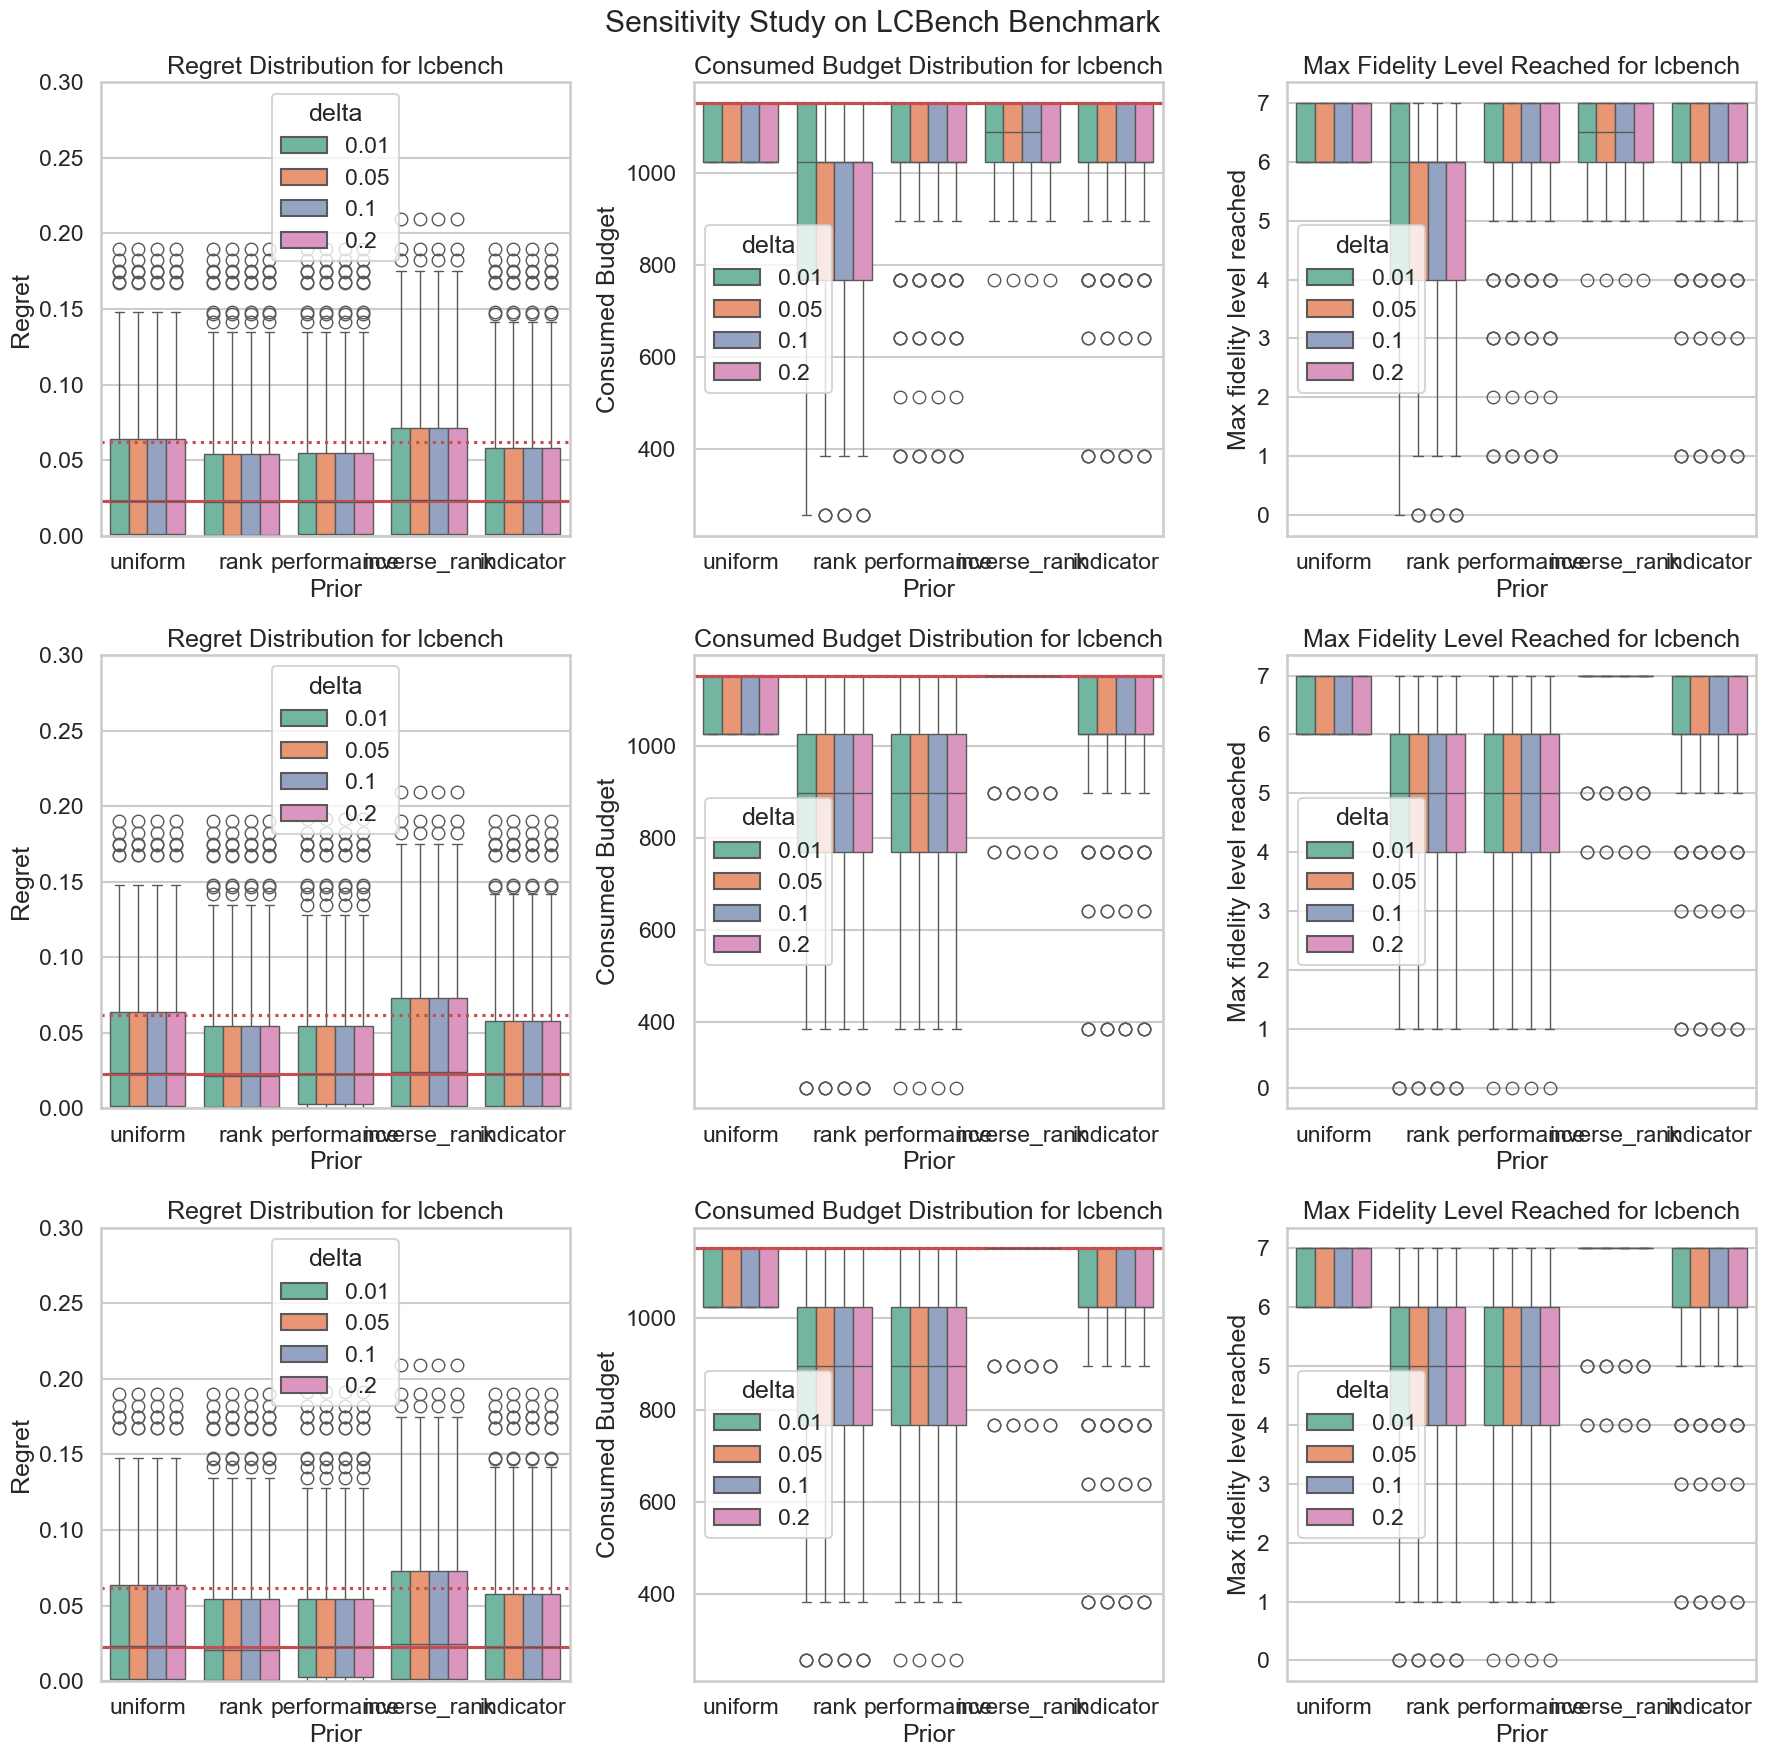

In [70]:
base_subset = predicted_performance_sensitivity[(predicted_performance_sensitivity["epsilon"] == 0.01)]
sensitivity_plots(base_subset, merged_successive_halving, "lcbench", "Sensitivity Study on LCBench Benchmark", sigmas = [0.01, 0.001, 0.0001], hue="delta")

### Real Performance

Successive Halving Mean Regret: 0.022693028068542453, Std Dev: 0.039084108962017146
Successive Halving Mean Consumed Budget: 1152.0, Std Dev: 0.0


/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_10608/2758826522.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_10608/2758826522.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_10608/2758826522.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


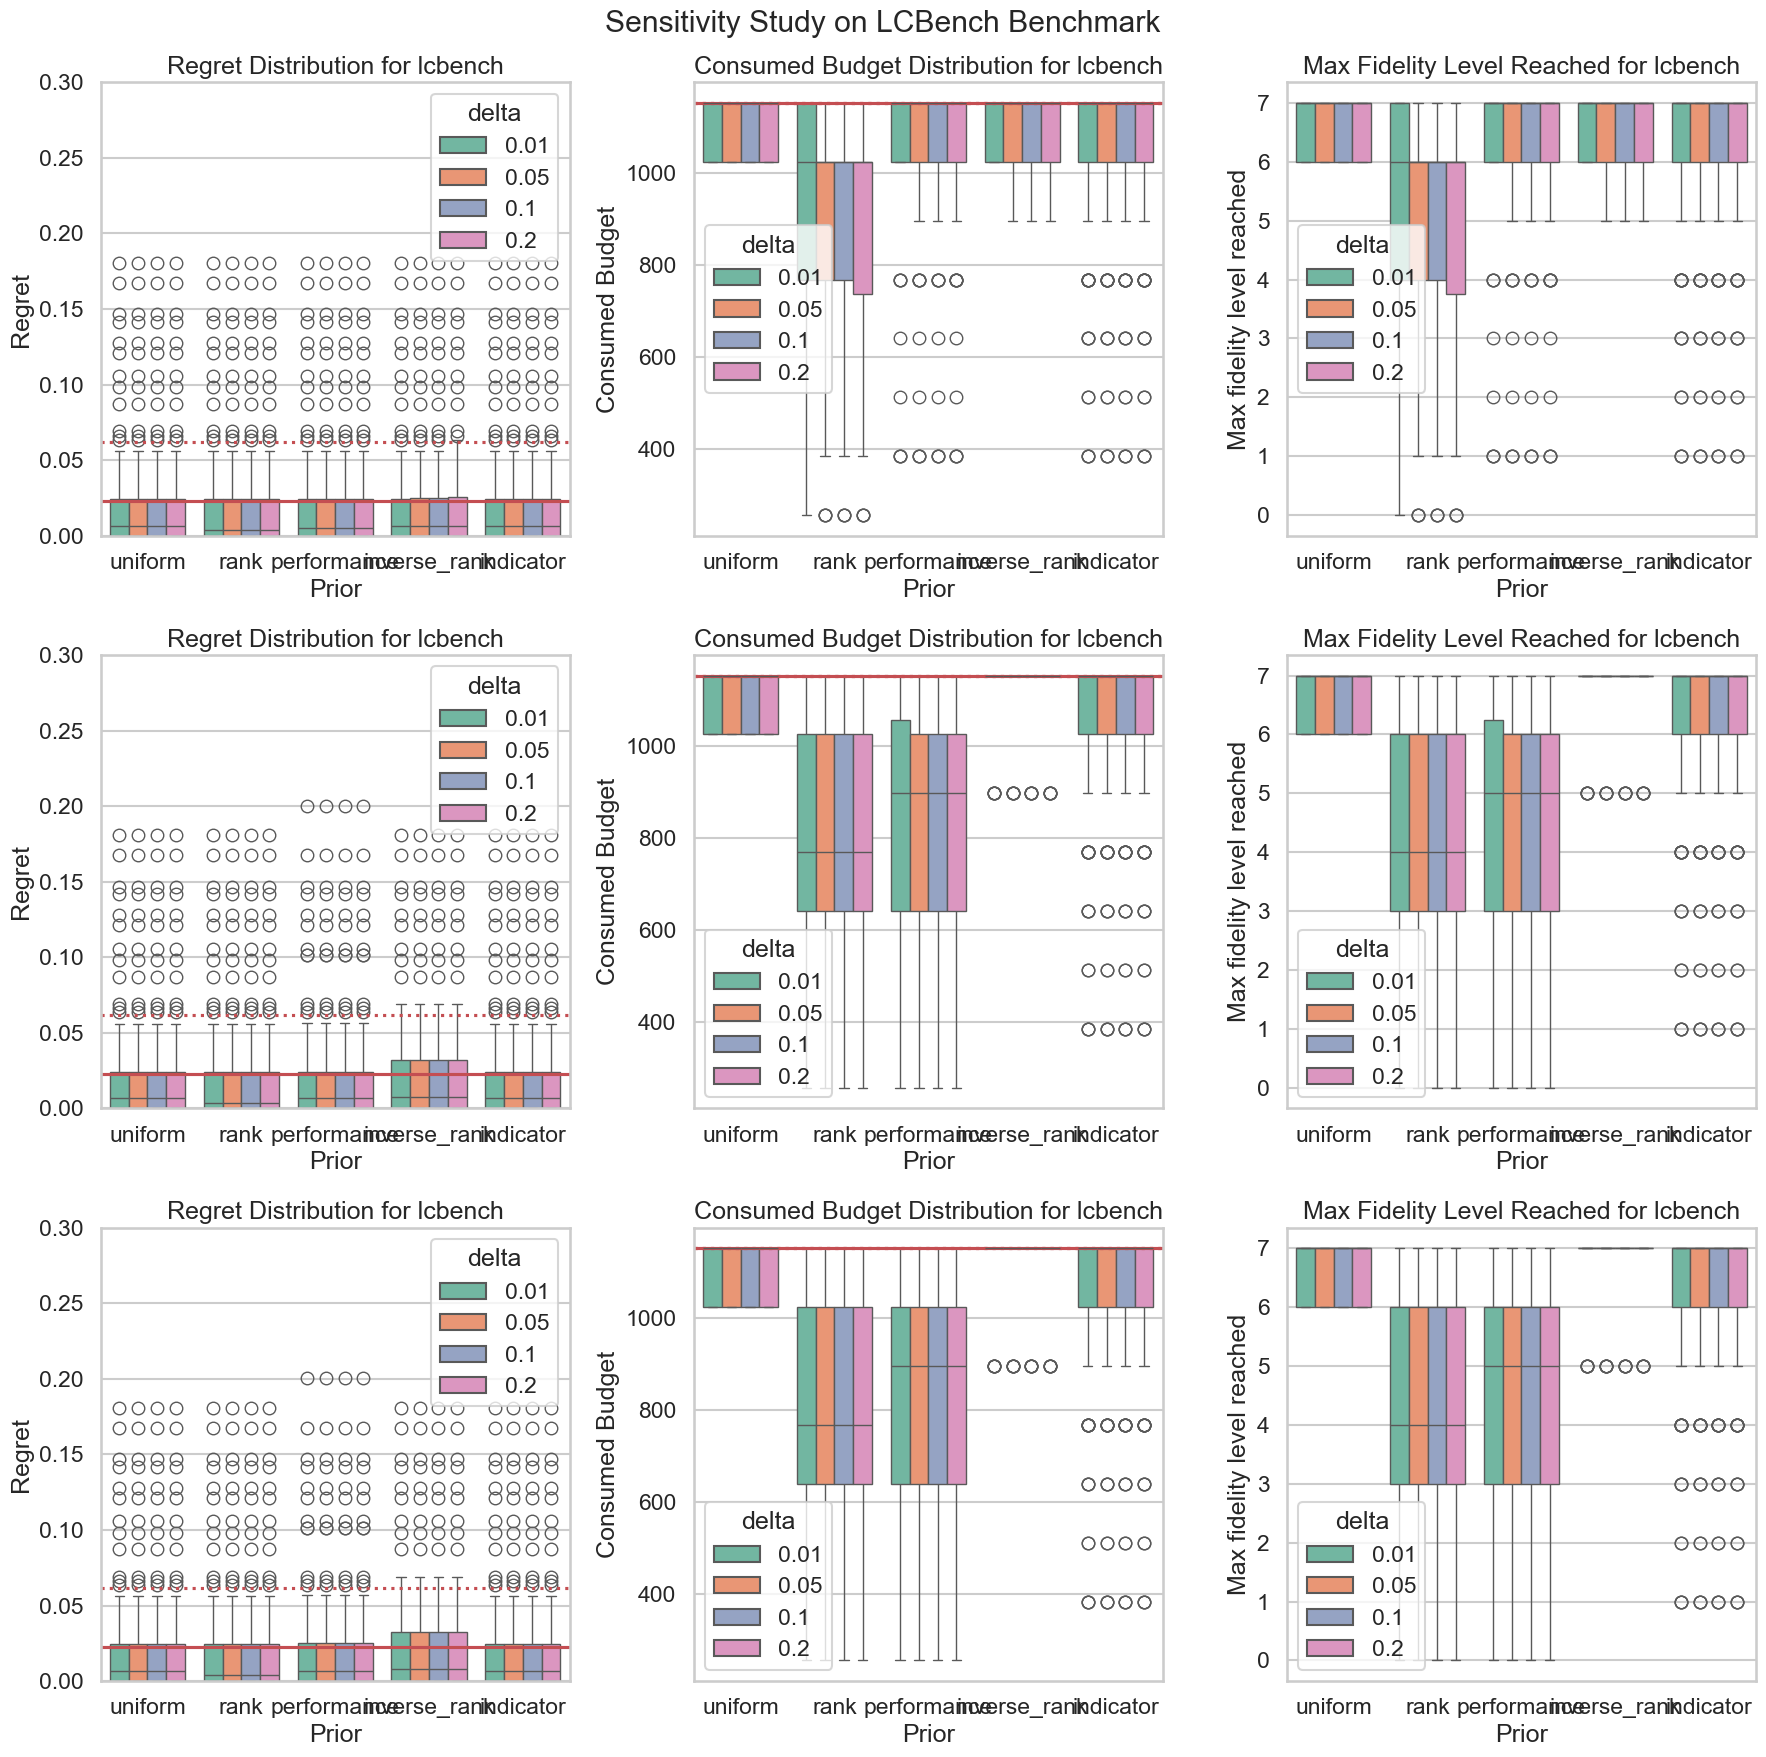

In [71]:
base_subset = real_performance_sensitivity[(real_performance_sensitivity["epsilon"] == 0.01)]
sensitivity_plots(base_subset, merged_successive_halving, "lcbench", "Sensitivity Study on LCBench Benchmark", sigmas = [0.01, 0.001, 0.0001], hue="delta")

## Predicted Performance Sensitivity, with varying epsilon
### Predicted Performance

Successive Halving Mean Regret: 0.022693028068542453, Std Dev: 0.039084108962017146
Successive Halving Mean Consumed Budget: 1152.0, Std Dev: 0.0


/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_10608/2758826522.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_10608/2758826522.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_10608/2758826522.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


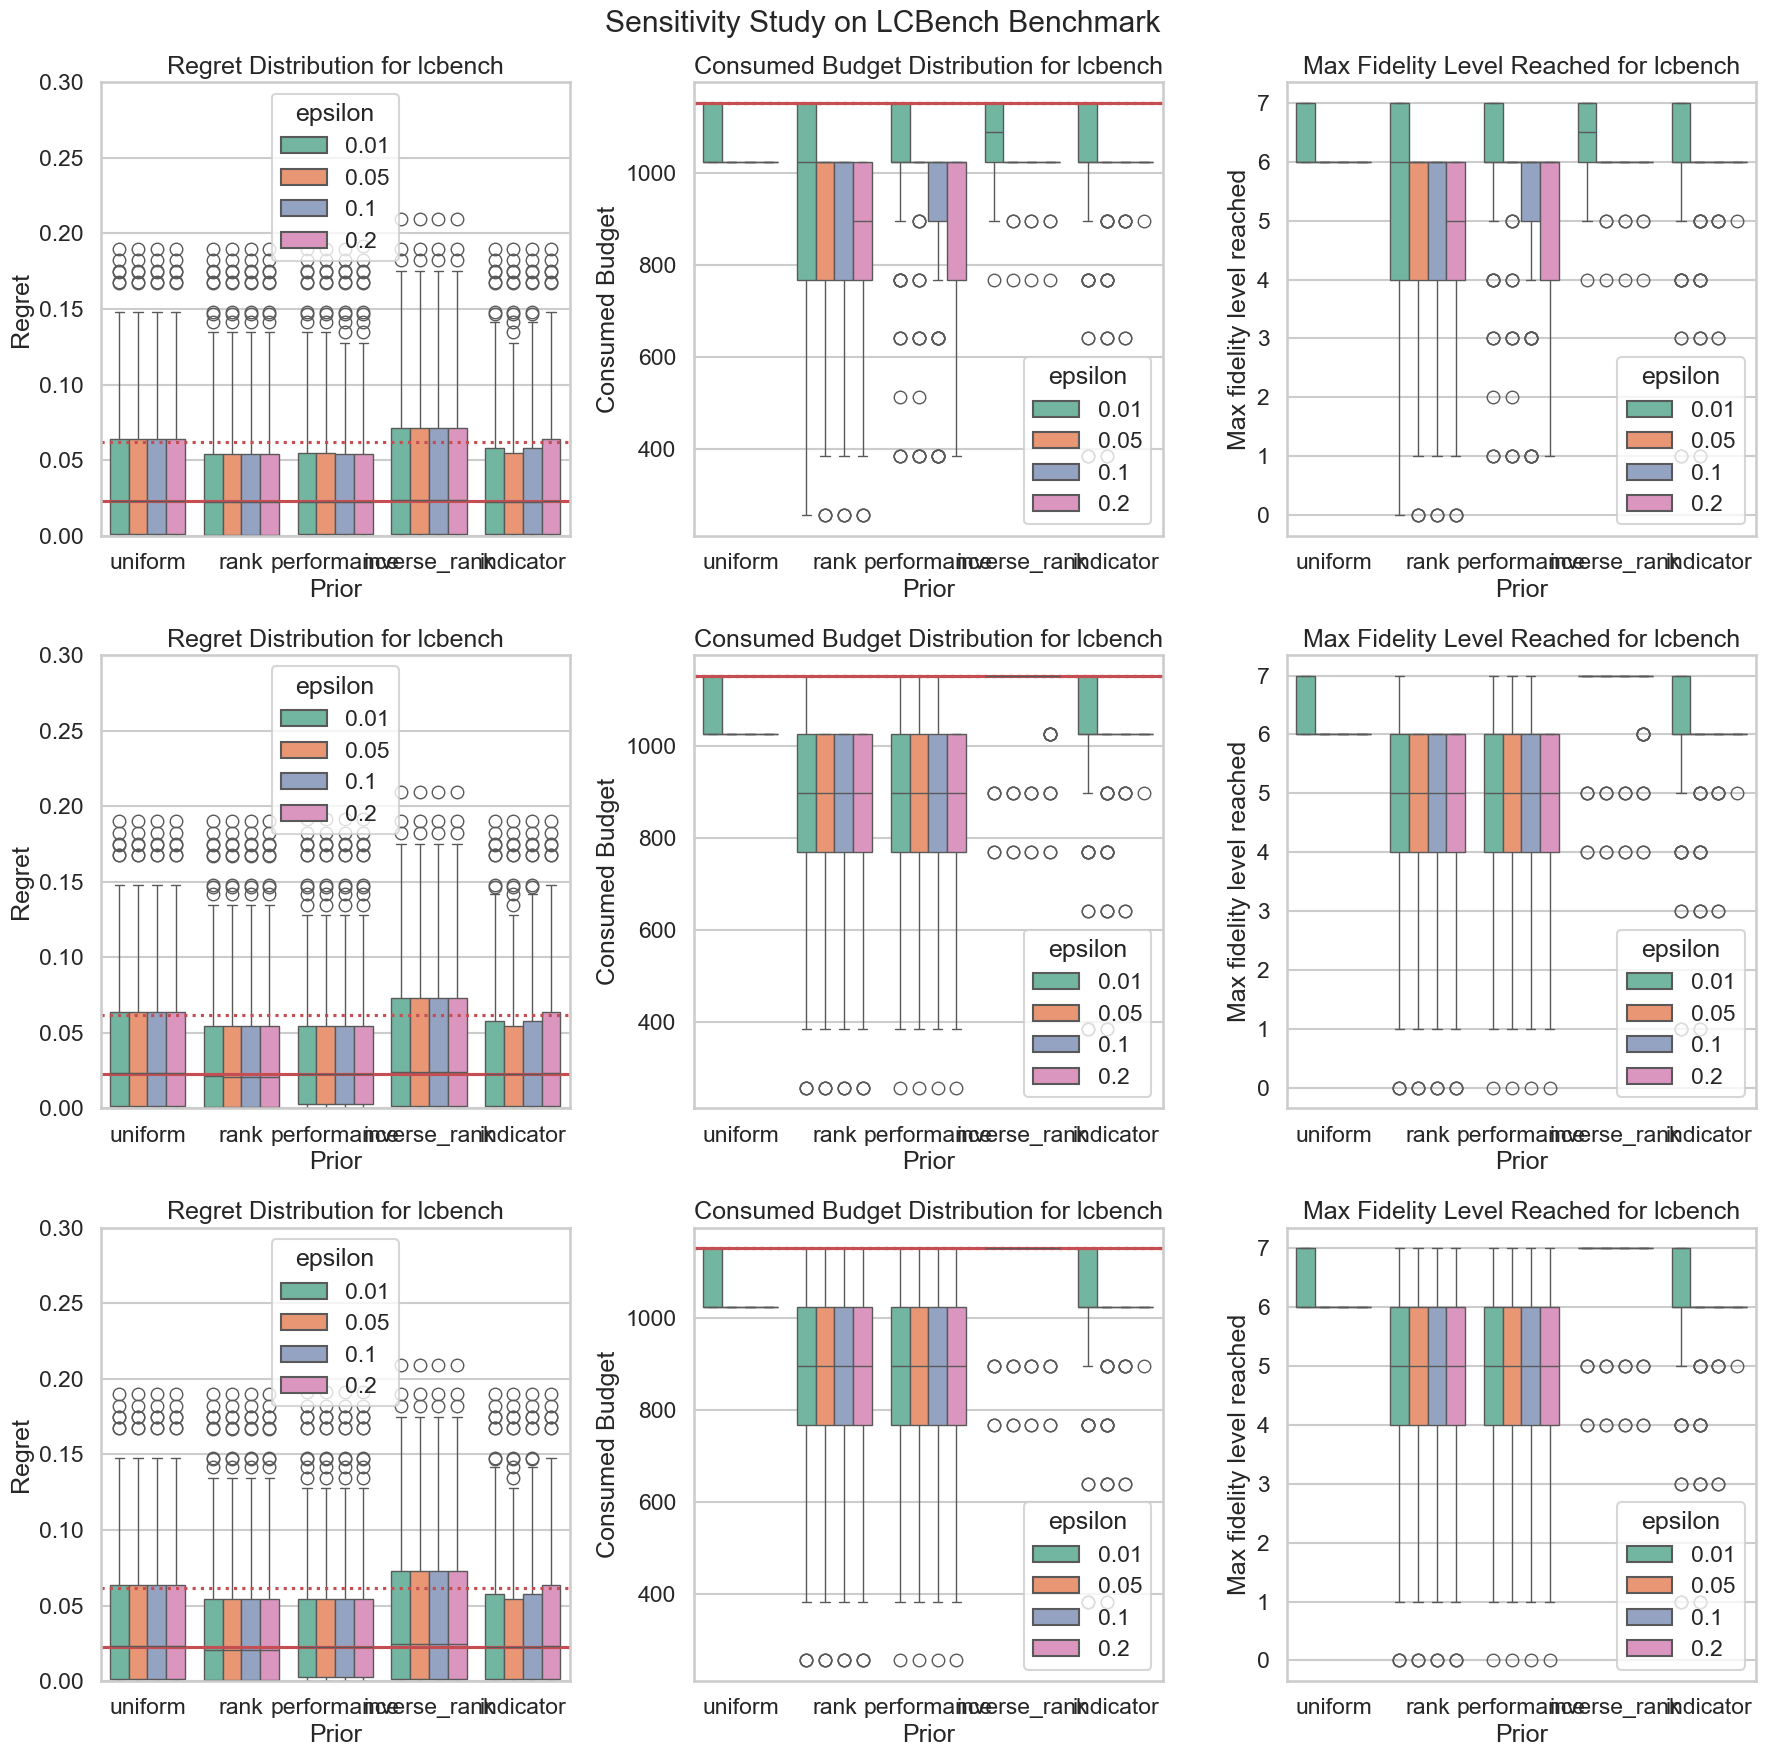

In [72]:
base_subset = predicted_performance_sensitivity[(predicted_performance_sensitivity["delta"] == 0.01)]
sensitivity_plots(base_subset, merged_successive_halving,"lcbench", "Sensitivity Study on LCBench Benchmark", sigmas = [0.01, 0.001, 0.0001], hue="epsilon")

### Real Performance

Successive Halving Mean Regret: 0.022693028068542453, Std Dev: 0.039084108962017146
Successive Halving Mean Consumed Budget: 1152.0, Std Dev: 0.0


/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_10608/2758826522.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_10608/2758826522.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_10608/2758826522.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


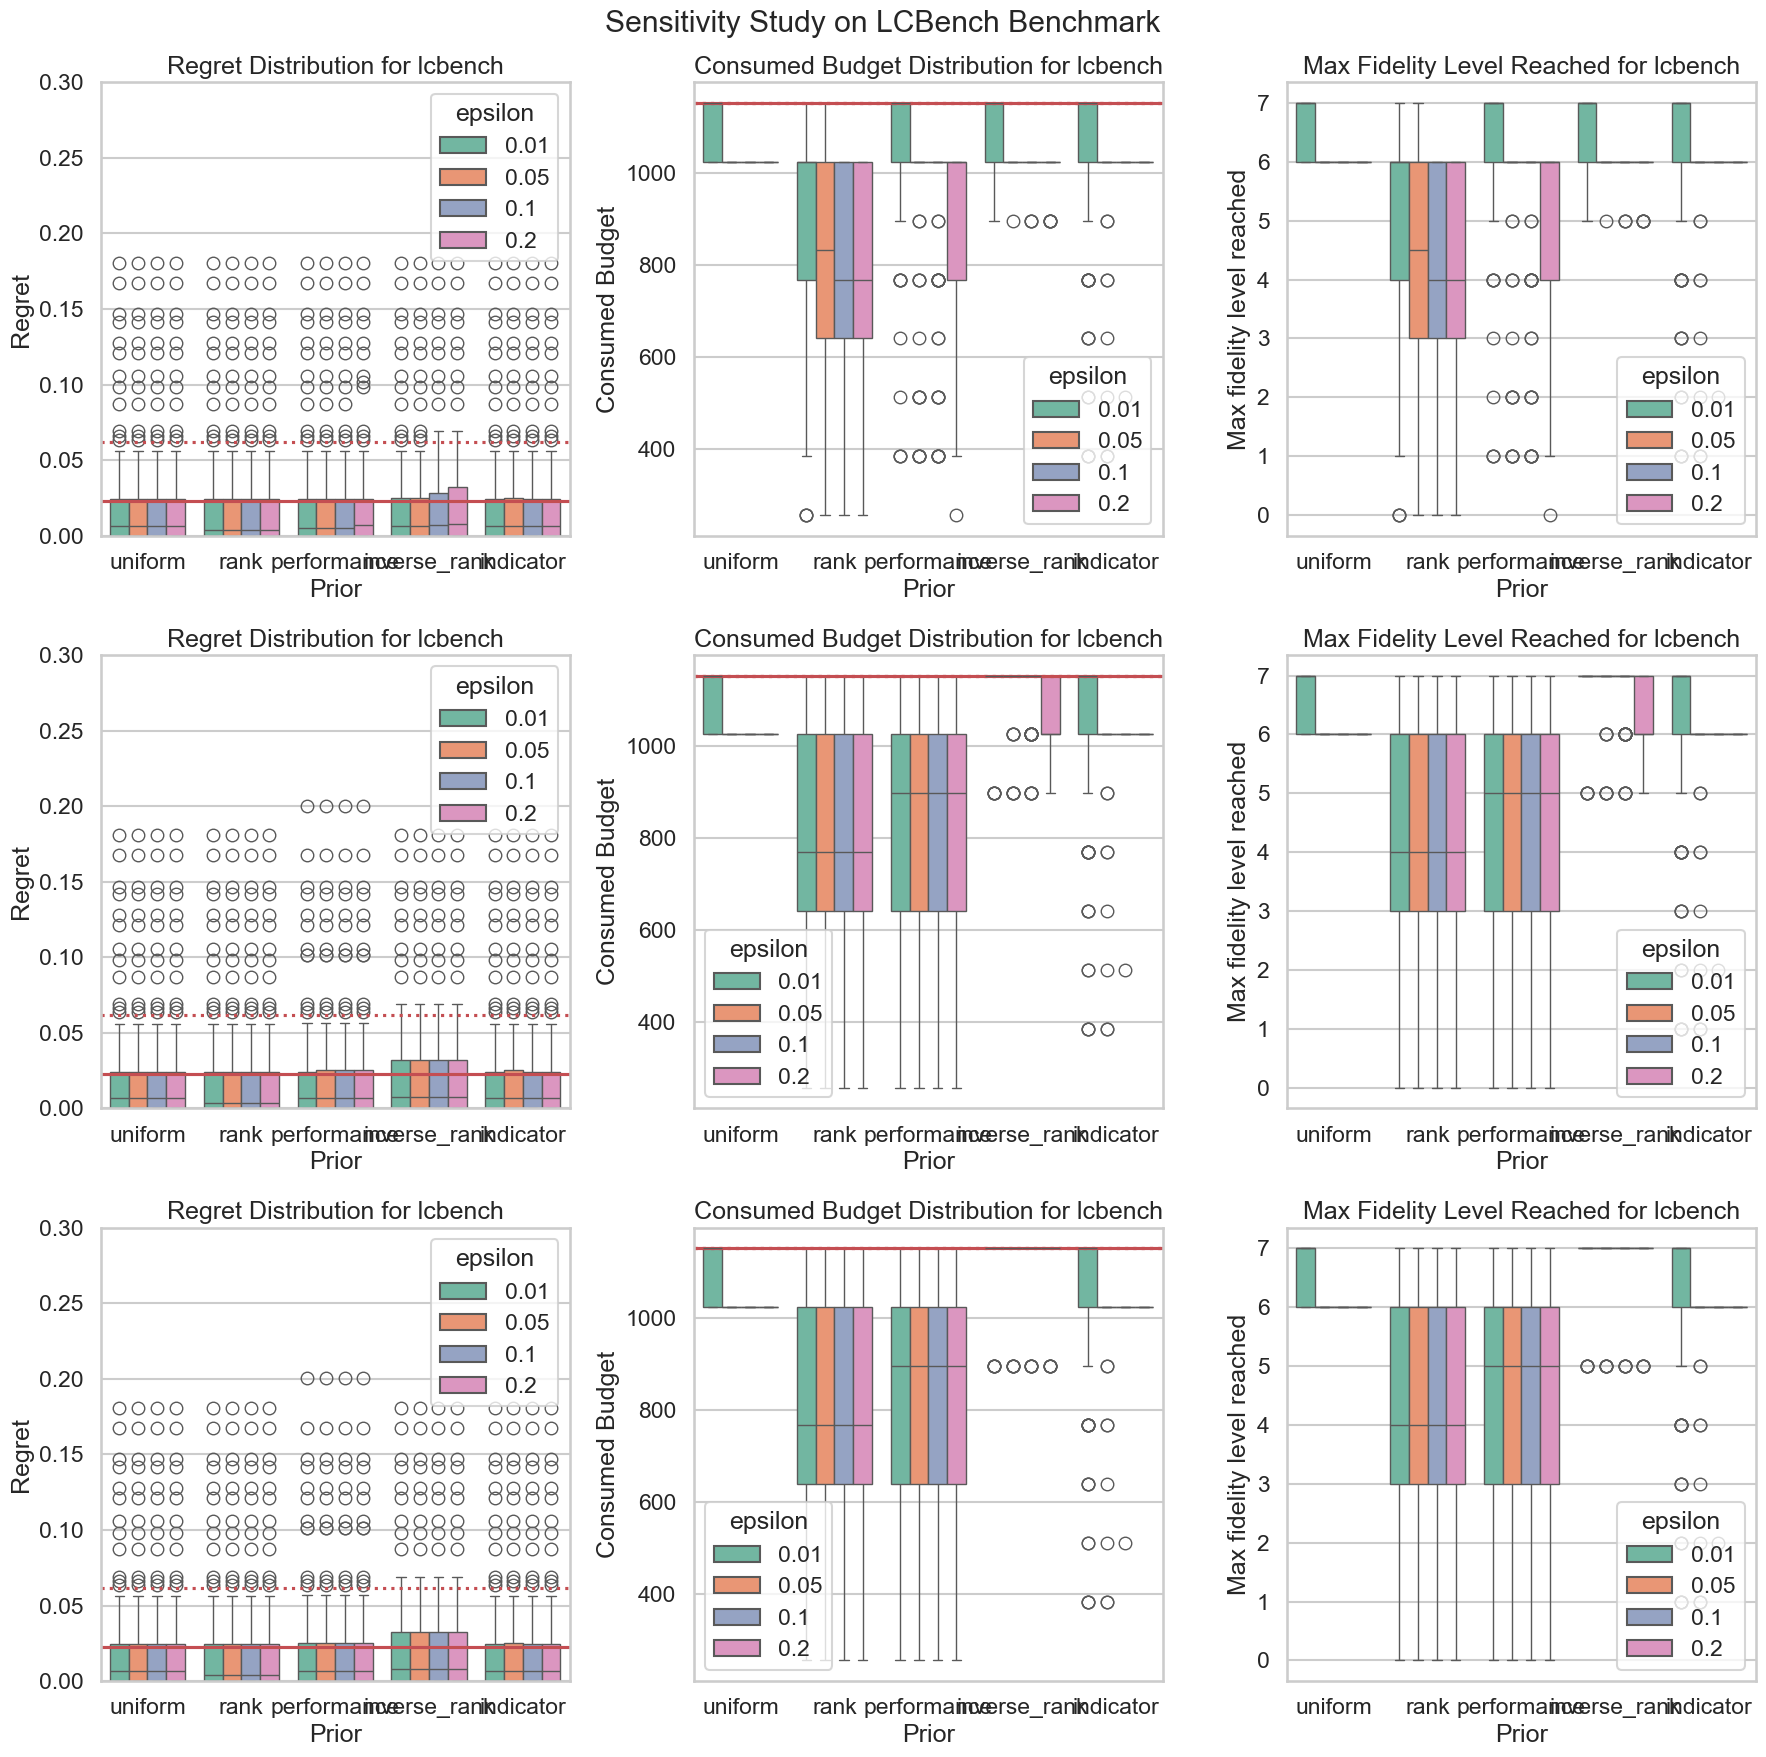

In [73]:
base_subset = real_performance_sensitivity[(real_performance_sensitivity["delta"] == 0.1)]
sensitivity_plots(base_subset, merged_successive_halving, "lcbench", "Sensitivity Study on LCBench Benchmark", sigmas = [0.01, 0.001, 0.0001], hue="epsilon")

# Final Results Table

In [74]:
def final_plots(merged_df: pd.DataFrame, benchmark_name: str, fig_title: str, sigmas:list[float], hue:str = None):
    def create_boxplot(sigma_data,x,y,ax):
        # Set more obvious colors in the plot
        if hue is not None:
            sns.boxplot(data=sigma_data, x=x, y=y, hue=hue, ax=ax, palette="Set2")
        else:
            sns.boxplot(data=sigma_data, x=x, y=y, ax=ax, palette="Set2")

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(fig_title)

    create_boxplot(merged_df, "prior", "regret", ax[0])
    ax[0].set_title(f"Regret Distribution for {benchmark_name}")
    ax[0].set_ylabel("Regret")
    ax[0].set_xlabel("Prior")
    ax[0].set_ylim(0, 0.3)

    # Create boxplot for consumed budget
    create_boxplot(merged_df, "prior", "consumed_budget", ax[1])
    ax[1].set_title(f"Consumed Budget Distribution for {benchmark_name}")
    ax[1].set_ylabel("Consumed Budget")
    ax[1].set_xlabel("Prior")

In [183]:
def rename_priors(df: pd.DataFrame) -> pd.DataFrame:
    rename_dict = {
        "uniform": "Uniform",
        "performance": "Performance",
        "rank": "Rank",
        "inverse_rank": "Inverse Rank",
        "indicator": "Indicator",
    }

    df['prior'] = df['prior'].map(rename_dict).fillna(df['prior'])
    return df

def pareto_fron_idea(base_subset: pd.DataFrame):
    sns.set_theme(style="whitegrid", context="talk")
    
    # 1. Rank priors by mean consumed_budget
    ranked_priors = (
        base_subset.groupby("prior")["consumed_budget"]
        .mean()
        .sort_values(ascending=True)
        .index.tolist()
    )
    
    palette = sns.color_palette("colorblind", n_colors=len(ranked_priors))
    fig, ax = plt.subplots(figsize=(8, 5))

    # 2. Iterate using the ranked list
    for i, prior in enumerate(ranked_priors):
        prior_data = base_subset[base_subset["prior"] == prior]
        
        m_reg, s_reg = prior_data["regret"].mean(), prior_data["regret"].sem()
        m_bud, s_bud = prior_data["consumed_budget"].mean(), prior_data["consumed_budget"].sem()
        
        # SWAPPED: m_bud is now X, m_reg is now Y
        ax.errorbar(
            m_bud, m_reg, 
            xerr=s_bud, yerr=s_reg, 
            fmt='o', label=prior,
            color=palette[i],
            markersize=9,
            capsize=3,
            markeredgewidth=0,
            alpha=0.9
        )

    # Updated labels to match swapped axes
    ax.set_xlabel("Consumed Budget")
    ax.set_ylabel("Regret")
    
    # Move legend below the plot
    # ncol puts labels in a row; loc='upper center' with bbox below 0 anchor
    ax.legend(
        loc='upper center', 
        bbox_to_anchor=(0.5, -0.28), 
        ncol=3, # Adjust ncol based on your number of priors
        frameon=True
    )
    
    plt.tight_layout()
    
    return fig

In [184]:
base_subset = real_performance_sensitivity[(real_performance_sensitivity["delta"] == 0.1) & (real_performance_sensitivity["epsilon"] == 0.01)]
# Add baseline to base_subset
successive_halving_table = merged_successive_halving.assign(prior="Standard SH")
successive_halving_table["sigma0"] = "Standard SH"  # or another appropriate value
base_subset = pd.concat([base_subset, successive_halving_table])
base_subset = rename_priors(base_subset)


In [185]:
base_subset

,ID,run_id,num_arms_final,benchmark,kernel,use_predicted_y,use_early_stopping,seed,prior,performance_prior_std,...,best_arm,end_date,error,experiment_id,timestamp,iteration,num_arms_logtable,best_arm_included,budget_spent_so_far,N_stop
158444,24001,__AUTO__,256,lcbench,linear,0,1,0,Uniform,0.01,...,1,2026-01-25 22:11:30,NaN,24001,2026-01-25 22:11:29,7,2,1,1152.0,527.865818
158459,24003,__AUTO__,256,lcbench,linear,0,1,1,Uniform,0.01,...,0,2026-01-25 22:23:28,NaN,24003,2026-01-25 22:23:27,6,4,0,1024.0,822.028629
158475,24005,__AUTO__,256,lcbench,linear,0,1,2,Uniform,0.01,...,1,2026-01-25 21:57:01,NaN,24005,2026-01-25 21:56:59,7,2,1,1152.0,527.865818
158490,24007,__AUTO__,256,lcbench,linear,0,1,3,Uniform,0.01,...,0,2026-01-25 22:22:26,NaN,24007,2026-01-25 22:22:26,6,4,0,1024.0,729.827310
158504,24009,__AUTO__,256,lcbench,linear,0,1,4,Uniform,0.01,...,1,2026-01-25 22:13:25,NaN,24009,2026-01-25 22:13:23,6,4,1,1024.0,303.463961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4300,574,__AUTO__,256,lcbench,linear,0,0,95,Standard SH,0.01,...,0,2026-01-26 16:53:48,NaN,574,2026-01-26 16:53:48,7,2,0,1152.0,5.278658
4345,580,__AUTO__,256,lcbench,linear,0,0,96,Standard SH,0.01,...,1,2026-01-26 16:55:23,NaN,580,2026-01-26 16:55:23,7,2,1,1152.0,5.278658
4390,586,__AUTO__,256,lcbench,linear,0,0,97,Standard SH,0.01,...,1,2026-01-26 16:53:44,NaN,586,2026-01-26 16:53:44,7,2,1,1152.0,5.278658
4435,592,__AUTO__,256,lcbench,linear,0,0,98,Standard SH,0.01,...,0,2026-01-26 16:55:19,NaN,592,2026-01-26 16:55:19,7,2,0,1152.0,5.278658


In [186]:
successive_halving_table["regret"].mean()

0.022693028068542453

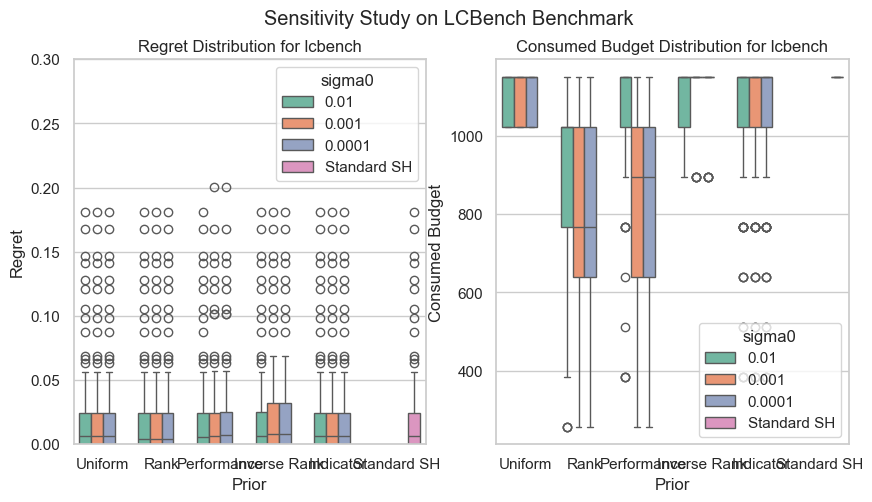

In [187]:
final_plots(base_subset, "lcbench", "Sensitivity Study on LCBench Benchmark", sigmas = [0.01, 0.001, 0.0001], hue="sigma0")

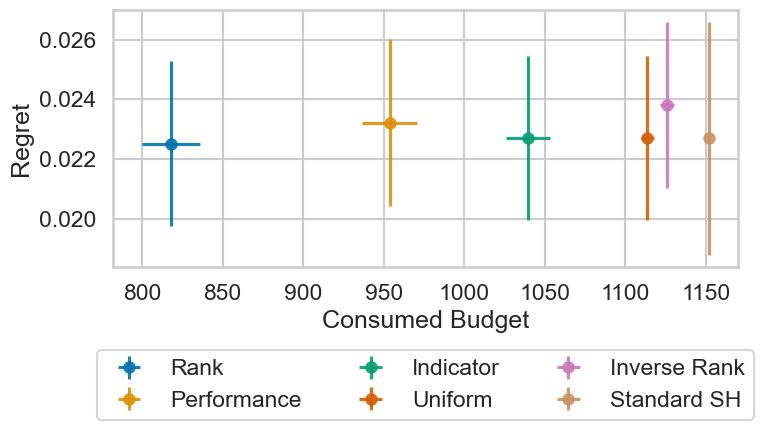

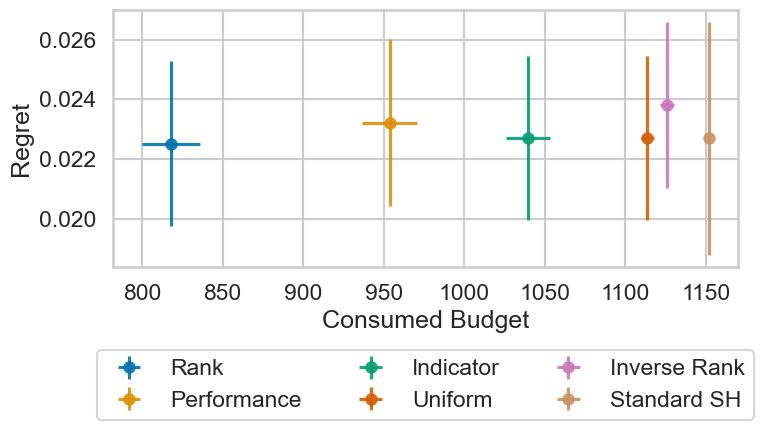

In [ ]:
# base subset for pareto front idea
base_subset = base_subset[(base_subset["sigma0"] == "Successive Halving") | (base_subset["sigma0"] != 0.001)]
pareto_fron_idea(base_subset).savefig("plots/pareto_front_idea_lcbench.pdf", bbox_inches='tight')
pareto_fron_idea(base_subset).savefig("plots/pareto_front_idea_lcbench.png", bbox_inches='tight')